In [ ]:
# !uv pip install scikit-learn
# !uv pip install ftfy regex git+https://github.com/openai/CLIP.git

In [ ]:
import torch
# Download the dataset
from torchvision.datasets import CIFAR10
from torch.utils.data.dataloader import DataLoader
from torchvision.transforms import transforms


# Prepaare dataset

In [ ]:

NUMBER_EXAMPLES = 1000
preprocess = transforms.Compose([
    # Resize to 224x224 using BICUBIC for cleaner upscaling from 32x32
    transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.BICUBIC),
    
    # Convert to Tensor (scales pixels to 0.0 - 1.0 and changes shape to C, H, W)
    transforms.ToTensor(),
    
    # Normalize using standard ImageNet mean and std (required by DINOv2)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
cifar10 = CIFAR10(root="./cifar_10/", download=True, train=False, transform=preprocess)
cifar10.data = cifar10.data[:NUMBER_EXAMPLES]
data_loader = DataLoader(cifar10, batch_size=4)

# dinov2

In [ ]:
dinov2_vitb14 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')

In [6]:
dino_embeddings, labels = [], []
dinov2_vitb14.eval()
with torch.no_grad():
    for x, y in data_loader:
        dino_embeddings.append(dinov2_vitb14(x))
        labels.append(y)
dino_embeddings = torch.cat(dino_embeddings)
labels = torch.cat(labels)

In [15]:
labels.shape, dino_embeddings.shape

(torch.Size([1000]), torch.Size([1000, 768]))

### CLIP

In [ ]:
import torch
import clip
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)
cifar10_clip = CIFAR10(root="./cifar_10/", download=True, train=False)


In [ ]:
clip_embeddings = []

for i in range(NUMBER_EXAMPLES):
    image, class_id = cifar10_clip[i]
    image_input = preprocess(image).unsqueeze(0).to(device)
    # Calculate features
    with torch.no_grad():
        clip_image_features = model.encode_image(image_input)

    # Pick the top 5 most similar labels for the image
    clip_embeddings.append( clip_image_features / clip_image_features.norm(dim=-1, keepdim=True))
clip_embeddings = torch.cat(clip_embeddings)
clip_embeddings.shape

torch.Size([1000, 512])

# Compare both models using K-NN

In [12]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

y = labels.cpu().numpy()
idx = np.arange(len(y))
tr, te = train_test_split(idx, test_size=0.3, stratify=y, random_state=0)

def knn_acc(emb):
    X = emb.cpu().numpy()
    knn = KNeighborsClassifier(n_neighbors=10, metric="cosine").fit(X[tr], y[tr])
    return knn.score(X[te], y[te])

print(f"DINOv2 k-NN acc: {knn_acc(dino_embeddings):.3f}")
print(f"CLIP   k-NN acc: {knn_acc(clip_embeddings):.3f}")

DINOv2 k-NN acc: 0.967
CLIP   k-NN acc: 0.907


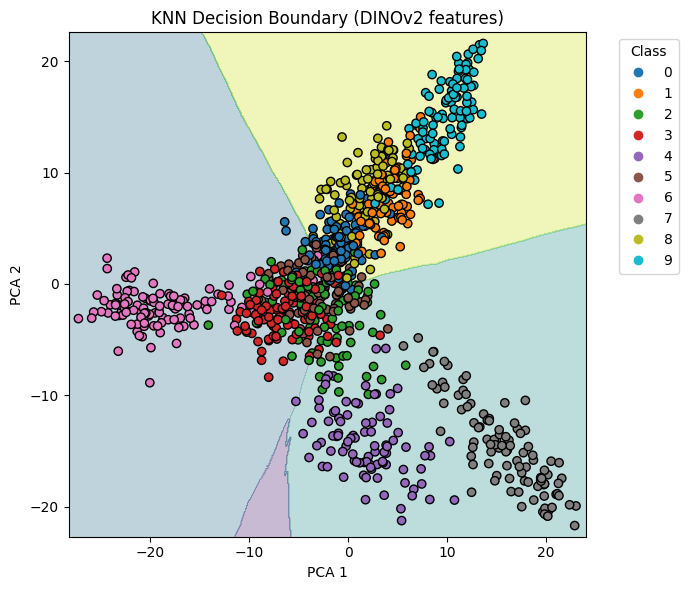

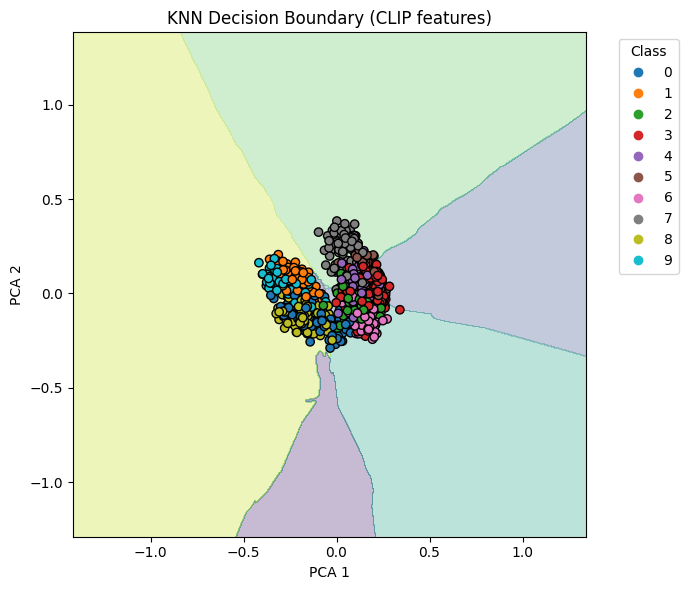

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def plot_knn_decision(X_emb, y_true, knn_model, title):
    from sklearn.decomposition import PCA

    # Reduce to 2D using PCA for visualization
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_emb)

    # Create a mesh grid for the 2D PCA space
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )
    grid_points = np.c_[xx.ravel(), yy.ravel()]

    # Project the grid back to original embedding space for prediction
    # (by inverting PCA transform)
    grid_original_space = pca.inverse_transform(grid_points)
    Z = knn_model.predict(grid_original_space)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, Z, alpha=0.3)
    scatter = plt.scatter(
        X_2d[:, 0], X_2d[:, 1], c=y_true, edgecolor="k", cmap='tab10'
    )
    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend(*scatter.legend_elements(), title="Class", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Visualize KNN decision boundary for DINO
dino_knn = KNeighborsClassifier(n_neighbors=10, metric="cosine").fit(dino_embeddings.cpu().numpy(),labels.cpu().numpy())
clip_knn = KNeighborsClassifier(n_neighbors=10, metric="cosine").fit(clip_embeddings.cpu().numpy(),labels.cpu().numpy())
plot_knn_decision(
    X_emb=dino_embeddings.cpu().numpy(),
    y_true=labels.cpu().numpy(),
    knn_model=dino_knn,
    title="KNN Decision Boundary (DINOv2 features)"
)

# Visualize KNN decision boundary for CLIP
plot_knn_decision(
    X_emb=clip_embeddings.cpu().numpy(),
    y_true=labels.cpu().numpy(),
    knn_model=clip_knn,
    title="KNN Decision Boundary (CLIP features)"
)

### Summary

* So in the end DinoV2 beats CLIP for only visual based tasks for example just classification using visual embeddings or similarity search. My recommendatin for future - for image to image search to be using dinoV2 model instead of CLIP